/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.4375 - loss: 0.9892 - val_accuracy: 0.3750 - val_loss: 0.9993
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6354 - loss: 0.9045 - val_accuracy: 0.5833 - val_loss: 0.9476
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6979 - loss: 0.8310 - val_accuracy: 0.5833 - val_loss: 0.9009
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7396 - loss: 0.7726 - val_accuracy: 0.5833 - val_loss: 0.8595
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7708 - loss: 0.7247 - val_accuracy: 0.5833 - val_loss: 0.8255
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7917 - loss: 0.6843 - val_accuracy: 0.6250 - val_loss: 0.7951
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8125 - loss: 0.6487 - val_accuracy: 0.6250 - val_loss: 0.7675
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8229 - loss: 0.6191 - val_accuracy: 0.6250 - 

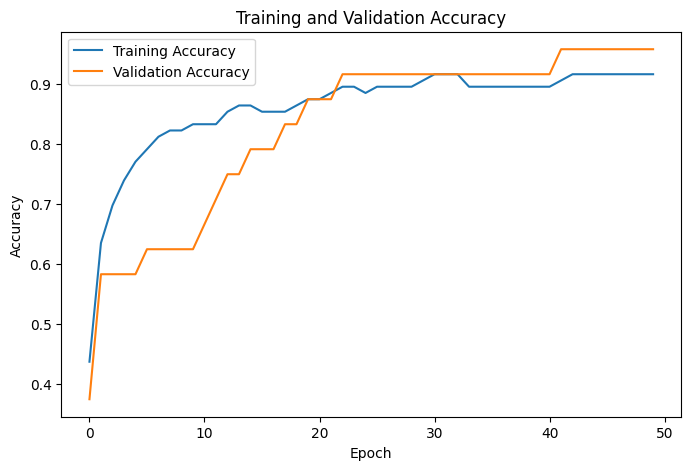

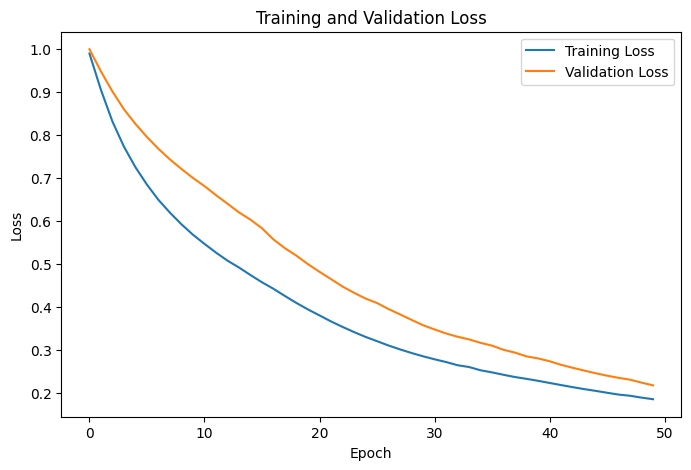

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


# --------------------------------------------------
# Load Iris Dataset
# --------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

# Convert target into categorical format
y = to_categorical(y, num_classes=3)


# --------------------------------------------------
# Split Dataset
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# --------------------------------------------------
# Standardize Features
# --------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# --------------------------------------------------
# Create Neural Network
# --------------------------------------------------

model = Sequential([
    Dense(16, activation="relu", input_shape=(4,)),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])


# --------------------------------------------------
# Compile Model
# --------------------------------------------------

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# --------------------------------------------------
# Train Model
# --------------------------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=10,
    validation_split=0.2,
    verbose=1
)


# --------------------------------------------------
# Evaluate Model
# --------------------------------------------------

loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n======================================")
print("NEURAL NETWORK RESULTS")
print("======================================")

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


# --------------------------------------------------
# Plot Training and Validation Accuracy
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


# --------------------------------------------------
# Plot Training and Validation Loss
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()